# Exploitation de données électorales avec Python

Antoine Rustenholz, Aziz Seghaier, Jasmin Neveu
31.04.2026

In [1]:
# On commence par importer les données depuis l'URL demandée.
import pandas as pd
df_main = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

/tmp/ipykernel_10200/2978571463.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_main = pd.read_csv(


In [2]:
# On en crée une copie afin d'éviter de multiplier les imports.
df = df_main.copy()

# Commençons par étudier nos données.
print(df.describe)
print(df.dtypes)
print(df.isna().sum())

<bound method NDFrame.describe of        code_departement              libelle_departement  code_commune  \
0                    01                              Ain             1   
1                    01                              Ain             2   
2                    01                              Ain             4   
3                    01                              Ain             5   
4                    01                              Ain             6   
...                 ...                              ...           ...   
528670      fr_etranger  Français établis hors de France           229   
528671      fr_etranger  Français établis hors de France           231   
528672      fr_etranger  Français établis hors de France           233   
528673      fr_etranger  Français établis hors de France           234   
528674      fr_etranger  Français établis hors de France           235   

                libelle_commune    prenom      nom  voix  
0       L'Abergeme

In [3]:
# On remarque que seule la variable prénom contient des valeurs manquantes, mais elles correspondent
# aux votes nuls, blancs et aux abstentions qui sont écrits dans la colomne 'nom'.
# Il est donc inutile de les remplir, ça ne serait qu'une répétition.

# On remarque que toutes les variables sont de type object sauf code_commune et voix qui sont de type int64.
# On convertit la variable code_commune en type object.
df['code_commune'] = df['code_commune'].astype(object)
print(df.dtypes)


code_departement       object
libelle_departement    object
code_commune           object
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
dtype: object


## 1. Explorations générales

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 1
</div>
</div>
<div class="callout-body-container callout-body">

Créer ou mettre à jour les variables suivantes:

-   `code_commune`: En utilisant la variable déjà existante et le département, remplacer la valeur `code_commune` pour constituer un vrai code commune. Par exemple, pour Montrouge, vous devriez obtenir 92049.

-   `candidat`: créer une colonne avec le prenom et le nom mis ensemble, en n’oubliant pas de mettre un espace. Ne pas éliminer les bulletins abstentions, blancs ou nuls, nous allons les exploiter ultérieurement.

</div>
</div>

In [4]:
import numpy as np

# Pour créer un vrai code commune, il suffit de concaténer les codes du départements et de la commune
# en ajoutant des zéros afin d'avoir toujours un code à 5 chiffres.
df['code_commune'] = (
    df['code_departement'].astype(str).str.zfill(2) +
    df['code_commune'].astype(str).str.zfill(3)
)

# On fait juste attention aux votes non exprimés.
df['candidat'] = np.where(
    pd.isna(df['prenom']),
    df['nom'],
    df['prenom'] + ' ' + df['nom']
)

df.sample(10)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
461335,10,Aube,10009,Arrelles,NaN,blancs,0,blancs
369083,45,Loiret,45239,Oussoy-en-Gâtinais,Philippe,POUTOU,2,Philippe POUTOU
380568,71,Saône-et-Loire,71350,Pierreclos,Philippe,POUTOU,2,Philippe POUTOU
336414,53,Mayenne,53033,La Boissière,Valérie,PÉCRESSE,8,Valérie PÉCRESSE
467676,26,Drôme,26188,Mollans-sur-Ouvèze,NaN,blancs,10,blancs
218698,21,Côte-d'Or,21297,Gilly-lès-Cîteaux,Jean-Luc,MÉLENCHON,62,Jean-Luc MÉLENCHON
201486,64,Pyrénées-Atlantiques,64418,Noguères,Éric,ZEMMOUR,2,Éric ZEMMOUR
465007,2B,Haute-Corse,2B193,Omessa,NaN,blancs,10,blancs
443282,55,Meuse,55395,Osches,NaN,abstentions,3,abstentions
413193,65,Hautes-Pyrénées,65100,Bordères-sur-l'Echez,Nicolas,DUPONT-AIGNAN,43,Nicolas DUPONT-AIGNAN


<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 2
</div>
</div>
<div class="callout-body-container callout-body">

Compléter la phrase suivante grâce à Python:
En 2022, il y avait XXXXX candidats à l’élection présidentielle.
*Note: Attention aux votes non exprimés et aux abstentions*

</div>
</div>

In [5]:
# Il suffit de compter le nombre de valeurs différentes pour candidats en supprimant les abstentions, les votes blancs et nuls.
f"En 2022, il y avait {df['candidat'].nunique()-3} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 3
</div>
</div>
<div class="callout-body-container callout-body">

Calculer les scores nationaux de chaque candidat. Représenter dans ce tableau, pour chaque candidat, le nombre de voix et le pourcatage des votes exprimés (c’est-à-dire en retirant abstentions et votes non exprimés).
Représenter cela dans un *dataframe* ou, pour avoir tous les points, dans un tableau mis en forme via `great_tables` (il n’est pas obligatoire d’aller aussi loin dans la mise en forme mais essayez d’obtenir un beau tableau tout de même).
*Note: vous pouvez contrôler vos résultats obtenus avec cette page.*

</div>
</div>

In [6]:
from great_tables import GT

# Création d'une table auxiliaire
resultats = (
    df[['candidat', 'voix']]
    .groupby('candidat', as_index = False).sum()
)

# Suppression des non-candidats
resultats = resultats[~resultats['candidat'].isin(['abstentions', 'nuls', 'blancs'])]

# Calcul du nombre total de voix exprimées
nombre_total = resultats['voix'].sum()

# Création de la variable score
resultats['score'] = resultats['voix'] / nombre_total

# Tri
resultats = resultats.sort_values('voix', ascending=False)


# Génération du tableau
(
    GT(resultats)
    .tab_header(
        title = "Elections présidentielles 2022",
        subtitle = "Résultats du premier tour (10 avril 2022)"
    )
    .cols_label( # Renommage des colonnes
        candidat = "Candidat",
        voix = "Nombre votes (total)",
        score = "Score (% votes exprimés)"
    )
    .fmt_number( # Formatage des nombres de voix
        columns = "voix",
        decimals = 0,
        sep_mark = ' '
    )
    .fmt_percent( # Formatage du score en pourcentage
        columns = "score",
        decimals = 2
    )
)

GT(_tbl_data=                 candidat     voix     score
1         Emmanuel MACRON  9783058  0.278458
5           Marine LE PEN  8133828  0.231516
4      Jean-Luc MÉLENCHON  7712520  0.219524
14           Éric ZEMMOUR  2485226  0.070738
9        Valérie PÉCRESSE  1679001  0.047790
10          Yannick JADOT  1627853  0.046334
3           Jean LASSALLE  1101387  0.031349
2          Fabien ROUSSEL   802422  0.022840
7   Nicolas DUPONT-AIGNAN   725176  0.020641
0            Anne HIDALGO   616478  0.017547
8         Philippe POUTOU   268904  0.007654
6        Nathalie ARTHAUD   197094  0.005610, _body=<great_tables._gt_data.Body object at 0x7fdc6ce97230>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fdc6ce96cf0>, _spanners=Spanners([]), _heading=Heading(title='Elections présidentielles 2022', subtitle='Résultats du premier tour (10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdc6ce97620>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fdc6cb40550>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fdc6ce97770>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fdc6ce974d0>, <great_tables._gt_data.FormatInfo object at 0x7fdc6cb40690>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_

## 2. Comparaison des scores départements aux moyennes nationales.

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 4
</div>
</div>
<div class="callout-body-container callout-body">

Créer un *dataframe* nommé `score_departements` stockant, pour chaque département, le nombre de vote obtenu pour chaque candidat et le score (en %).

</div>
</div>

In [7]:

df_exprimes = df[~df['candidat'].isin(['abstentions', 'nuls', 'blancs'])].copy()
votes_par_dept = (
    df_exprimes
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
)
score_departements = votes_par_dept.copy()
score_departements = score_departements.rename(columns={'voix': 'votes_departements'})
total_par_dept = (
    score_departements
    .groupby('code_departement')['votes_departements']
    .transform('sum')
)
score_departements['score_departement'] = (
    score_departements['votes_departements'] / total_par_dept
)

In [8]:
#---------------------------------------------------------------------------------------
# TEST SUR LE DEPARTEMENT DE L'AUDE
#---------------------------------------------------------------------------------------

score_departements_display = score_departements.copy()

score_departements_display = (
    score_departements_display[score_departements_display["code_departement"] == "11"]
)
score_departements_display.sort_values('score_departement', ascending=False, inplace=True)

score_departements_display = score_departements_display.rename(columns={
    'code_departement': 'Département',
    'candidat': 'Candidat',
    'votes_departements': 'Voix département',
    'score_departement': 'Score (%)'
})


(
    GT(score_departements_display)
    .tab_header(
        title="Scores de l'Aude",
        subtitle="Premier tour 2022"
    )
    .fmt_number(
        columns="Voix département",
        decimals=0,
        sep_mark=' '
    )
    .fmt_percent(
        columns="Score (%)",
        decimals=2
    )
)

GT(_tbl_data=    Département               Candidat  Voix département  Score (%)
125          11          Marine LE PEN             64027   0.301408
121          11        Emmanuel MACRON             43104   0.202913
124          11     Jean-Luc MÉLENCHON             42039   0.197900
131          11           Éric ZEMMOUR             18434   0.086778
123          11          Jean LASSALLE             12382   0.058289
129          11       Valérie PÉCRESSE              7350   0.034600
130          11          Yannick JADOT              6322   0.029761
120          11           Anne HIDALGO              6166   0.029027
122          11         Fabien ROUSSEL              5622   0.026466
127          11  Nicolas DUPONT-AIGNAN              4206   0.019800
128          11        Philippe POUTOU              1748   0.008229
126          11       Nathalie ARTHAUD              1026   0.004830, _body=<great_tables._gt_data.Body object at 0x7fdc6cc96b10>, _boxhead=Boxhead([ColInfo(var='Département', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='right', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Voix département', type=<ColInfoTypeEnum.default: 1>, column_label='Voix département', column_align='right', column_width=None), ColInfo(var='Score (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fdc6cb40a50>, _spanners=Spanners([]), _heading=Heading(title="Scores de l'Aude", subtitle='Premier tour 2022', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdc6cb40f50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fdc6cc96c40>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fdc6cb41450>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fdc6cb41590>, <great_tables._gt_data.FormatInfo object at 0x7fdc6cc96fd0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_bo

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 5
</div>
</div>
<div class="callout-body-container callout-body">

Refaire le lien avec le niveau national pour comparer le score départemental avec le score national. Nommer ce *dataframe* `score_departements`, nous allons le réutiliser par la suite.

</div>
</div>

In [9]:
candidats_liste = df_exprimes['candidat'].unique().tolist()
votes_nationaux = (
    df_exprimes
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_nationales'})
)
total_national = votes_nationaux['votes_nationales'].sum()
votes_nationaux['score_national'] = votes_nationaux['votes_nationales'] / total_national
score_departements = score_departements.merge(
    votes_nationaux[['candidat', 'votes_nationales', 'score_national']],
    on='candidat',
    how='left'
)

In [10]:
#---------------------------------------------------------------------------------------
# TEST SUR LE DEPARTEMENT DE L'AUDE
#---------------------------------------------------------------------------------------

score_departements_display = score_departements.copy()

score_departements_display = (
    score_departements_display[score_departements_display["code_departement"] == "11"]
)
score_departements_display.sort_values('score_departement', ascending=False, inplace=True)

score_departements_display = score_departements_display.rename(columns={
    'code_departement': 'Département',
    'candidat': 'Candidat',
    'votes_departements': 'Voix département',
    'score_departement': 'Score (%)',
    'votes_nationales': 'Voix nationales',
    'score_national': 'Score national (%)'
})


(
    GT(score_departements_display)
    .tab_header(
        title="Scores départementaux vs nationaux de l'Aude",
        subtitle="Premier tour 2022"
    )
    .fmt_number(
        columns=["Voix département", "Voix nationales"],
        decimals=0,
        sep_mark=' '
    )
    .fmt_percent(
        columns=["Score (%)", "Score national (%)"],
        decimals=2
    )
)

GT(_tbl_data=    Département               Candidat  Voix département  Score (%)  \
125          11          Marine LE PEN             64027   0.301408   
121          11        Emmanuel MACRON             43104   0.202913   
124          11     Jean-Luc MÉLENCHON             42039   0.197900   
131          11           Éric ZEMMOUR             18434   0.086778   
123          11          Jean LASSALLE             12382   0.058289   
129          11       Valérie PÉCRESSE              7350   0.034600   
130          11          Yannick JADOT              6322   0.029761   
120          11           Anne HIDALGO              6166   0.029027   
122          11         Fabien ROUSSEL              5622   0.026466   
127          11  Nicolas DUPONT-AIGNAN              4206   0.019800   
128          11        Philippe POUTOU              1748   0.008229   
126          11       Nathalie ARTHAUD              1026   0.004830   

     Voix nationales  Score national (%)  
125          8133828            0.231516  
121          9783058            0.278458  
124          7712520            0.219524  
131          2485226            0.070738  
123          1101387            0.031349  
129          1679001            0.047790  
130          1627853            0.046334  
120           616478            0.017547  
122           802422            0.022840  
127           725176            0.020641  
128           268904            0.007654  
126           197094            0.005610  , _body=<great_tables._gt_data.Body object at 0x7fdc6cad9150>, _boxhead=Boxhead([ColInfo(var='Département', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='right', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Voix département', type=<ColInfoTypeEnum.default: 1>, column_label='Voix département', column_align='right', column_width=None), ColInfo(var='Score (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None), ColInfo(var='Voix nationales', type=<ColInfoTypeEnum.default: 1>, column_label='Voix nationales', column_align='right', column_width=None), ColInfo(var='Score national (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score national (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fdc6cb41a90>, _spanners=Spanners([]), _heading=Heading(title="Scores départementaux vs nationaux de l'Aude", subtitle='Premier tour 2022', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdc6cc97490>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fdc6cb617f0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fdc6cb41d10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fdc6cc975c0>, <great_tables._gt_data.FormatInfo object at 0x7fdc6cb61d90>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_si

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 6
</div>
</div>
<div class="callout-body-container callout-body">

Créer une variable `surrepresentation` qui compare, en relatif, les scores nationaux et départementaux.
Par exemple, si un candidat a un score de 30% dans un département mais de 15% ailleurs, la valeur de `surrepresentation` sera égale à 100 (%).


</div>
</div>

In [11]:
score_departements['surrepresentation'] = (
    score_departements['score_departement']/score_departements['score_national']-1
    )

In [12]:
#---------------------------------------------------------------------------------------
# TEST SUR LE DEPARTEMENT DE L'AUDE
#---------------------------------------------------------------------------------------

score_departements_display = score_departements.copy()

score_departements_display = (
    score_departements_display[score_departements_display["code_departement"] == "11"]
)
score_departements_display.sort_values('score_departement', ascending=False, inplace=True)

score_departements_display = score_departements_display.rename(columns={
    'code_departement': 'Département',
    'candidat': 'Candidat',
    'votes_departements': 'Voix département',
    'score_departement': 'Score (%)',
    'votes_nationales': 'Voix nationales',
    'score_national': 'Score national (%)',
    'surrepresentation': 'Surrépresentation (%)'
})


(
    GT(score_departements_display)
    .tab_header(
        title="Surrépresentation dans l'Aude",
        subtitle="Écart relatif au score national (%) - Premier tour 2022"
    )
    .fmt_number(
        columns=["Voix département", "Voix nationales"],
        decimals=0,
        sep_mark=' '
    )
    .fmt_percent(
        columns=["Score (%)", "Score national (%)", "Surrépresentation (%)"],
        decimals=2
    )
)

GT(_tbl_data=    Département               Candidat  Voix département  Score (%)  \
125          11          Marine LE PEN             64027   0.301408   
121          11        Emmanuel MACRON             43104   0.202913   
124          11     Jean-Luc MÉLENCHON             42039   0.197900   
131          11           Éric ZEMMOUR             18434   0.086778   
123          11          Jean LASSALLE             12382   0.058289   
129          11       Valérie PÉCRESSE              7350   0.034600   
130          11          Yannick JADOT              6322   0.029761   
120          11           Anne HIDALGO              6166   0.029027   
122          11         Fabien ROUSSEL              5622   0.026466   
127          11  Nicolas DUPONT-AIGNAN              4206   0.019800   
128          11        Philippe POUTOU              1748   0.008229   
126          11       Nathalie ARTHAUD              1026   0.004830   

     Voix nationales  Score national (%)  Surrépresentation (%)  
125          8133828            0.231516               0.301892  
121          9783058            0.278458              -0.271298  
124          7712520            0.219524              -0.098506  
131          2485226            0.070738               0.226763  
123          1101387            0.031349               0.859336  
129          1679001            0.047790              -0.275992  
130          1627853            0.046334              -0.357688  
120           616478            0.017547               0.654218  
122           802422            0.022840               0.158764  
127           725176            0.020641              -0.040748  
128           268904            0.007654               0.075105  
126           197094            0.005610              -0.139044  , _body=<great_tables._gt_data.Body object at 0x7fdc6cb29650>, _boxhead=Boxhead([ColInfo(var='Département', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='right', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Voix département', type=<ColInfoTypeEnum.default: 1>, column_label='Voix département', column_align='right', column_width=None), ColInfo(var='Score (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None), ColInfo(var='Voix nationales', type=<ColInfoTypeEnum.default: 1>, column_label='Voix nationales', column_align='right', column_width=None), ColInfo(var='Score national (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score national (%)', column_align='right', column_width=None), ColInfo(var='Surrépresentation (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Surrépresentation (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fdc6cc97a80>, _spanners=Spanners([]), _heading=Heading(title="Surrépresentation dans l'Aude", subtitle='Écart relatif au score national (%) - Premier tour 2022', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdc6cad97b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fdc6cad98c0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fdc6cc976f0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fdc6cad9ae0>, <great_tables._gt_data.FormatInfo object at 0x7fdc6cad9e10>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='tab

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 7
</div>
</div>
<div class="callout-body-container callout-body">

Créer une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des
principales surreprésentations (en valeur absolue) par département.

</div>
</div>

In [13]:
import matplotlib.pyplot as plt
def plot_surrepresentation(candidat, n=5):
    df_candidat = score_departements[score_departements['candidat'] == candidat].copy()
    df_candidat = df_candidat.sort_values('surrepresentation', key=abs, ascending=False).head(n)

    plt.figure(figsize=(10, 6))
    colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_candidat['surrepresentation']]

    plt.barh(df_candidat['code_departement'], df_candidat['surrepresentation']*100, color=colors)
    plt.xlabel('Surrépresentation (%)')
    plt.ylabel('Département')
    plt.title(f'Top {n} des surreprésentations de {candidat}')
    plt.axvline(x=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

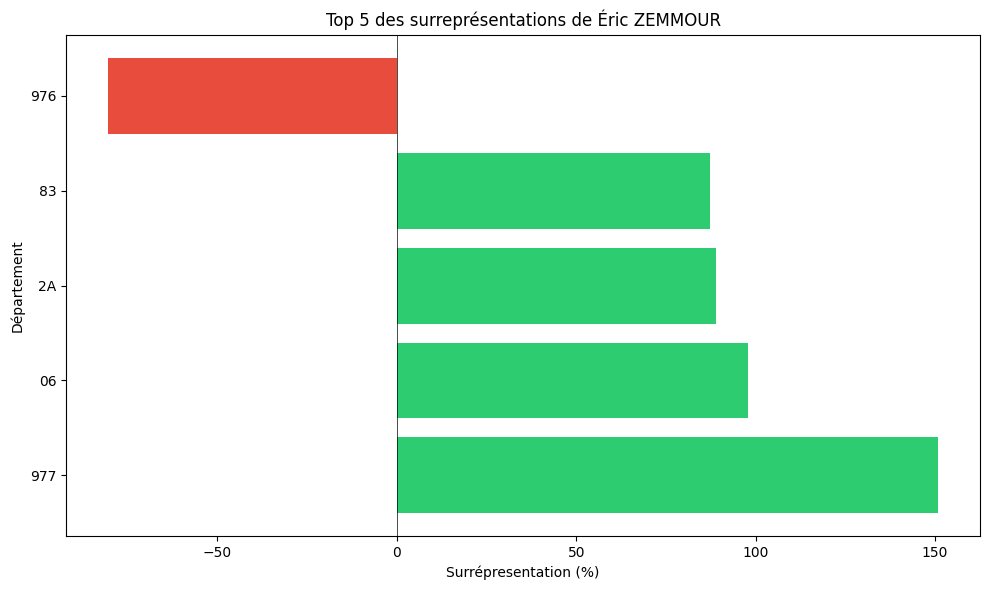

In [14]:
# Exemple avec Éric ZEMMOUR
plot_surrepresentation('Éric ZEMMOUR')

## 3. Un peu de cartographie

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 8
</div>
</div>
<div class="callout-body-container callout-body">

Faire une fonction permettant de restreindre `score_departements` en fonction d’un candidat. Commencer par tester sur Marine Le Pen (créer un nouvel objet, ne pas écraser `score_departements` nous allons l’utiliser à nouveau !).
Faire une jointure au fond de carte des départements et effectuer une carte de la représentation.

</div>
</div>

In [15]:
from cartiflette import carti_download
import matplotlib.colors as colors


departement_borders = carti_download(
    values = ["France"],
    crs = 4326,
    borders = "DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022)

merged_df = departement_borders.merge(
    score_departements,
    left_on="INSEE_DEP",
    right_on="code_departement"
)

merged_df['surrepresentation'] = merged_df['surrepresentation']*100

def map_surrepresentation(df, candidat_name):
    data_candidat = df[df['candidat'] == candidat_name]
    vmax = max(max(data_candidat['surrepresentation']), 30)
    vmin = min(min(data_candidat['surrepresentation']), -30)

    norm = colors.TwoSlopeNorm(
        vcenter=0,
        vmin=vmin,
        vmax=vmax
    )

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    data_candidat.plot(
        column='surrepresentation',
        cmap='RdBu_r',
        norm=norm,
        legend=True,
        ax=ax,
        edgecolor='black',
        linewidth=0.3,
        legend_kwds={'label': f"Surreprésentation de {candidat_name} (%)",
                     'orientation': "vertical", 'shrink': 0.6}
    )

    ax.set_axis_off()
    plt.title(f"Répartition territoriale : {candidat_name}", fontsize=15)
    plt.show()

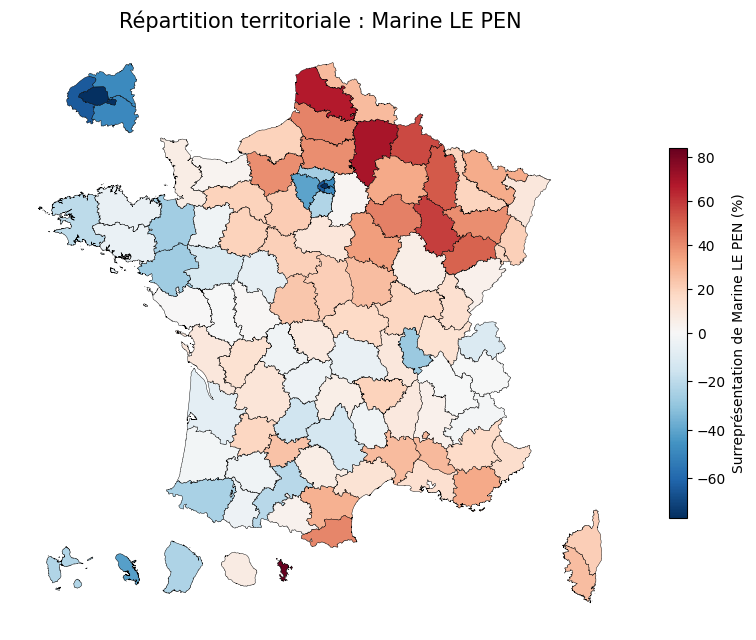

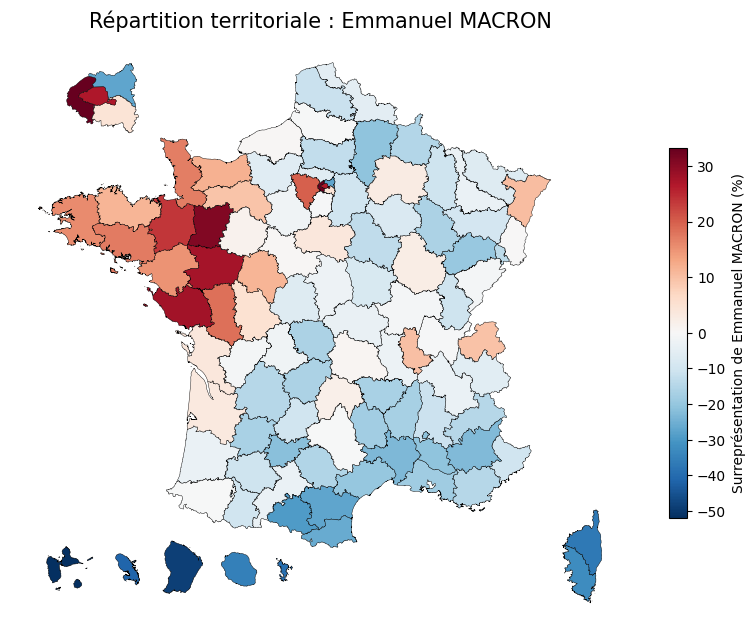

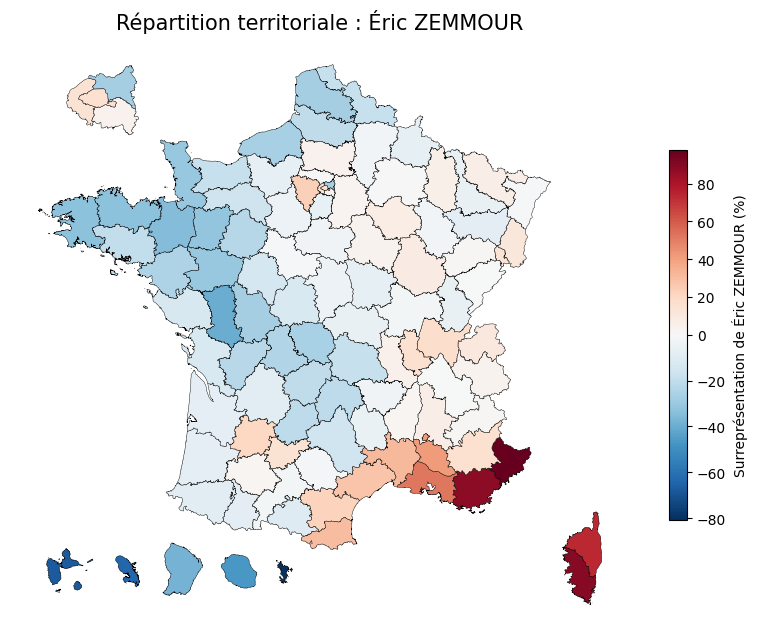

In [16]:
#test avec Le Pen, Macron et Zemmour
candidats = ['Marine LE PEN','Emmanuel MACRON','Éric ZEMMOUR']
for candidat in candidats:
    map_surrepresentation(merged_df, candidat)